While my group did the assignment in Python, I felt that this was an opportunity to learn R, so I have done that implementation as well as close to the assignment specs as it permits. I say as close as because its equivalent of sckikit-learn, caret, doesn't always make available the same information because of its implementation (such as training epochs).

I know this likely won't count for anything, but I wanted to present my work regardless.

Note: This does not cover to the very end because the limitations of caret relative to scikit-learn were becoming apparent. I had to write the code in RStudio and transfer it to colab as colab took ages to run, mainly from installing the necessary packages.

# Imports and Initialization

In [ ]:
# Install system dependencies first
system("apt-get update -qq")
system("apt-get install -y libmagick++-dev")

In [ ]:
install.packages("tidyverse")
install.packages("GGally")
install.packages("plotly")
install.packages("summarytools")
install.packages("modelr")
install.packages("caret")
install.packages("glmnet")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘crosstalk’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lobstr’, ‘plyr’, ‘reshape2’, ‘checkmate’, ‘magick’, ‘matrixStats’, ‘pander’, ‘pryr’, ‘rapportools’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘time

In [ ]:
library(tidyverse)
library(ggplot2)
library(GGally)
library(plotly)
library(summarytools)
library(modelr)
library(caret)
library(glmnet)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout


Warning message:
“no DISPLAY variable so Tk is not available”

Attaching package: ‘summarytools’


The following object is masked from ‘package:tibble’:

    view


Loading required package: lattice


Attaching package: ‘caret’


The fo

In [ ]:
training_d <- read.csv('/content/happiness_data_train.csv')
test_d <- read.csv('/content/happiness_data_test.csv')

# Part A
Summarize the data. How much data is present? What attributes/features are continuous valued? Which attributes are categorical? [5 points]

In [ ]:
str(training_d)

'data.frame':	1559 obs. of  9 variables:
 $ Life.Ladder                     : num  4.93 5.37 7.38 4.61 6.18 ...
 $ Log.GDP.per.capita              : num  9.34 10.3 10.88 7.55 10.95 ...
 $ Social.support                  : num  0.766 0.901 0.931 0.724 NA 0.78 0.858 0.898 0.916 0.936 ...
 $ Healthy.life.expectancy.at.birth: num  64.2 67.5 72.6 60.6 65.8 ...
 $ Freedom.to.make.life.choices    : num  NA 0.754 0.942 0.702 NA 0.788 0.838 0.818 0.912 0.862 ...
 $ Generosity                      : num  -0.127 -0.201 0.077 -0.088 NA 0.008 0.087 0.105 0.096 -0.101 ...
 $ Perceptions.of.corruption       : num  0.709 0.726 0.263 0.768 NA 0.806 0.959 0.742 0.816 0.668 ...
 $ Positive.affect                 : num  0.669 0.702 0.823 0.566 NA 0.726 0.817 0.532 0.844 0.805 ...
 $ Negative.affect                 : num  0.331 0.199 0.161 0.195 NA 0.25 0.184 0.193 0.233 0.16 ...


In [ ]:
na_counts <- training_d %>%
  summarise_all(~ sum(!is.na(.))) %>%
  pivot_longer(everything(), names_to = "Variables", values_to = "Entries") %>%
  arrange(desc(Entries))

print(na_counts)

# A tibble: 9 × 2
  Variables                        Entries
  <chr>                              <int>
1 Life.Ladder                         1559
2 Social.support                      1549
3 Negative.affect                     1545
4 Positive.affect                     1542
5 Freedom.to.make.life.choices        1537
6 Log.GDP.per.capita                  1533
7 Healthy.life.expectancy.at.birth    1522
8 Generosity                          1488
9 Perceptions.of.corruption           1473


In [ ]:
1473 / 1559

[1] 0.9448364

There are 1559 data points representing 9 seperate variables. All are continuous. None are catergorical.

Life Ladder is the most complete, with a full 1559 entries. Perceptions of Corruption has the most missing data with 1473 / 1559 entries present (94.5%).

# Parts B / C
B. Display the statistical values for each of the attributes, along with visualizations (e.g., histogram) of the distributions for each attribute. Explain noticeable traits for key attributes. Are there any attributes that might require special treatment? If so, what special treatment might they require? [5 points]

C.	Analyze the relationships between the data attributes, and between the data attributes and label. This involves computing the Pearson Correlation Coefficient (PCC) and generating scatter plots. [10 points]

In [ ]:
# Resize plot window within Colab
options(repr.plot.width = 30, repr.plot.height = 20)


Notes:

... allows for passing of parameters such as size, color, etc

complete.obs ignores NA values

scales:col_numeric() : color-mapping function from within tidyverse


In [ ]:
options(warn=-1)
dfSummary(training_d) %>%
  print(method = "render")
options(warn=0)

Shiny tags cannot be represented in plain text (need html)

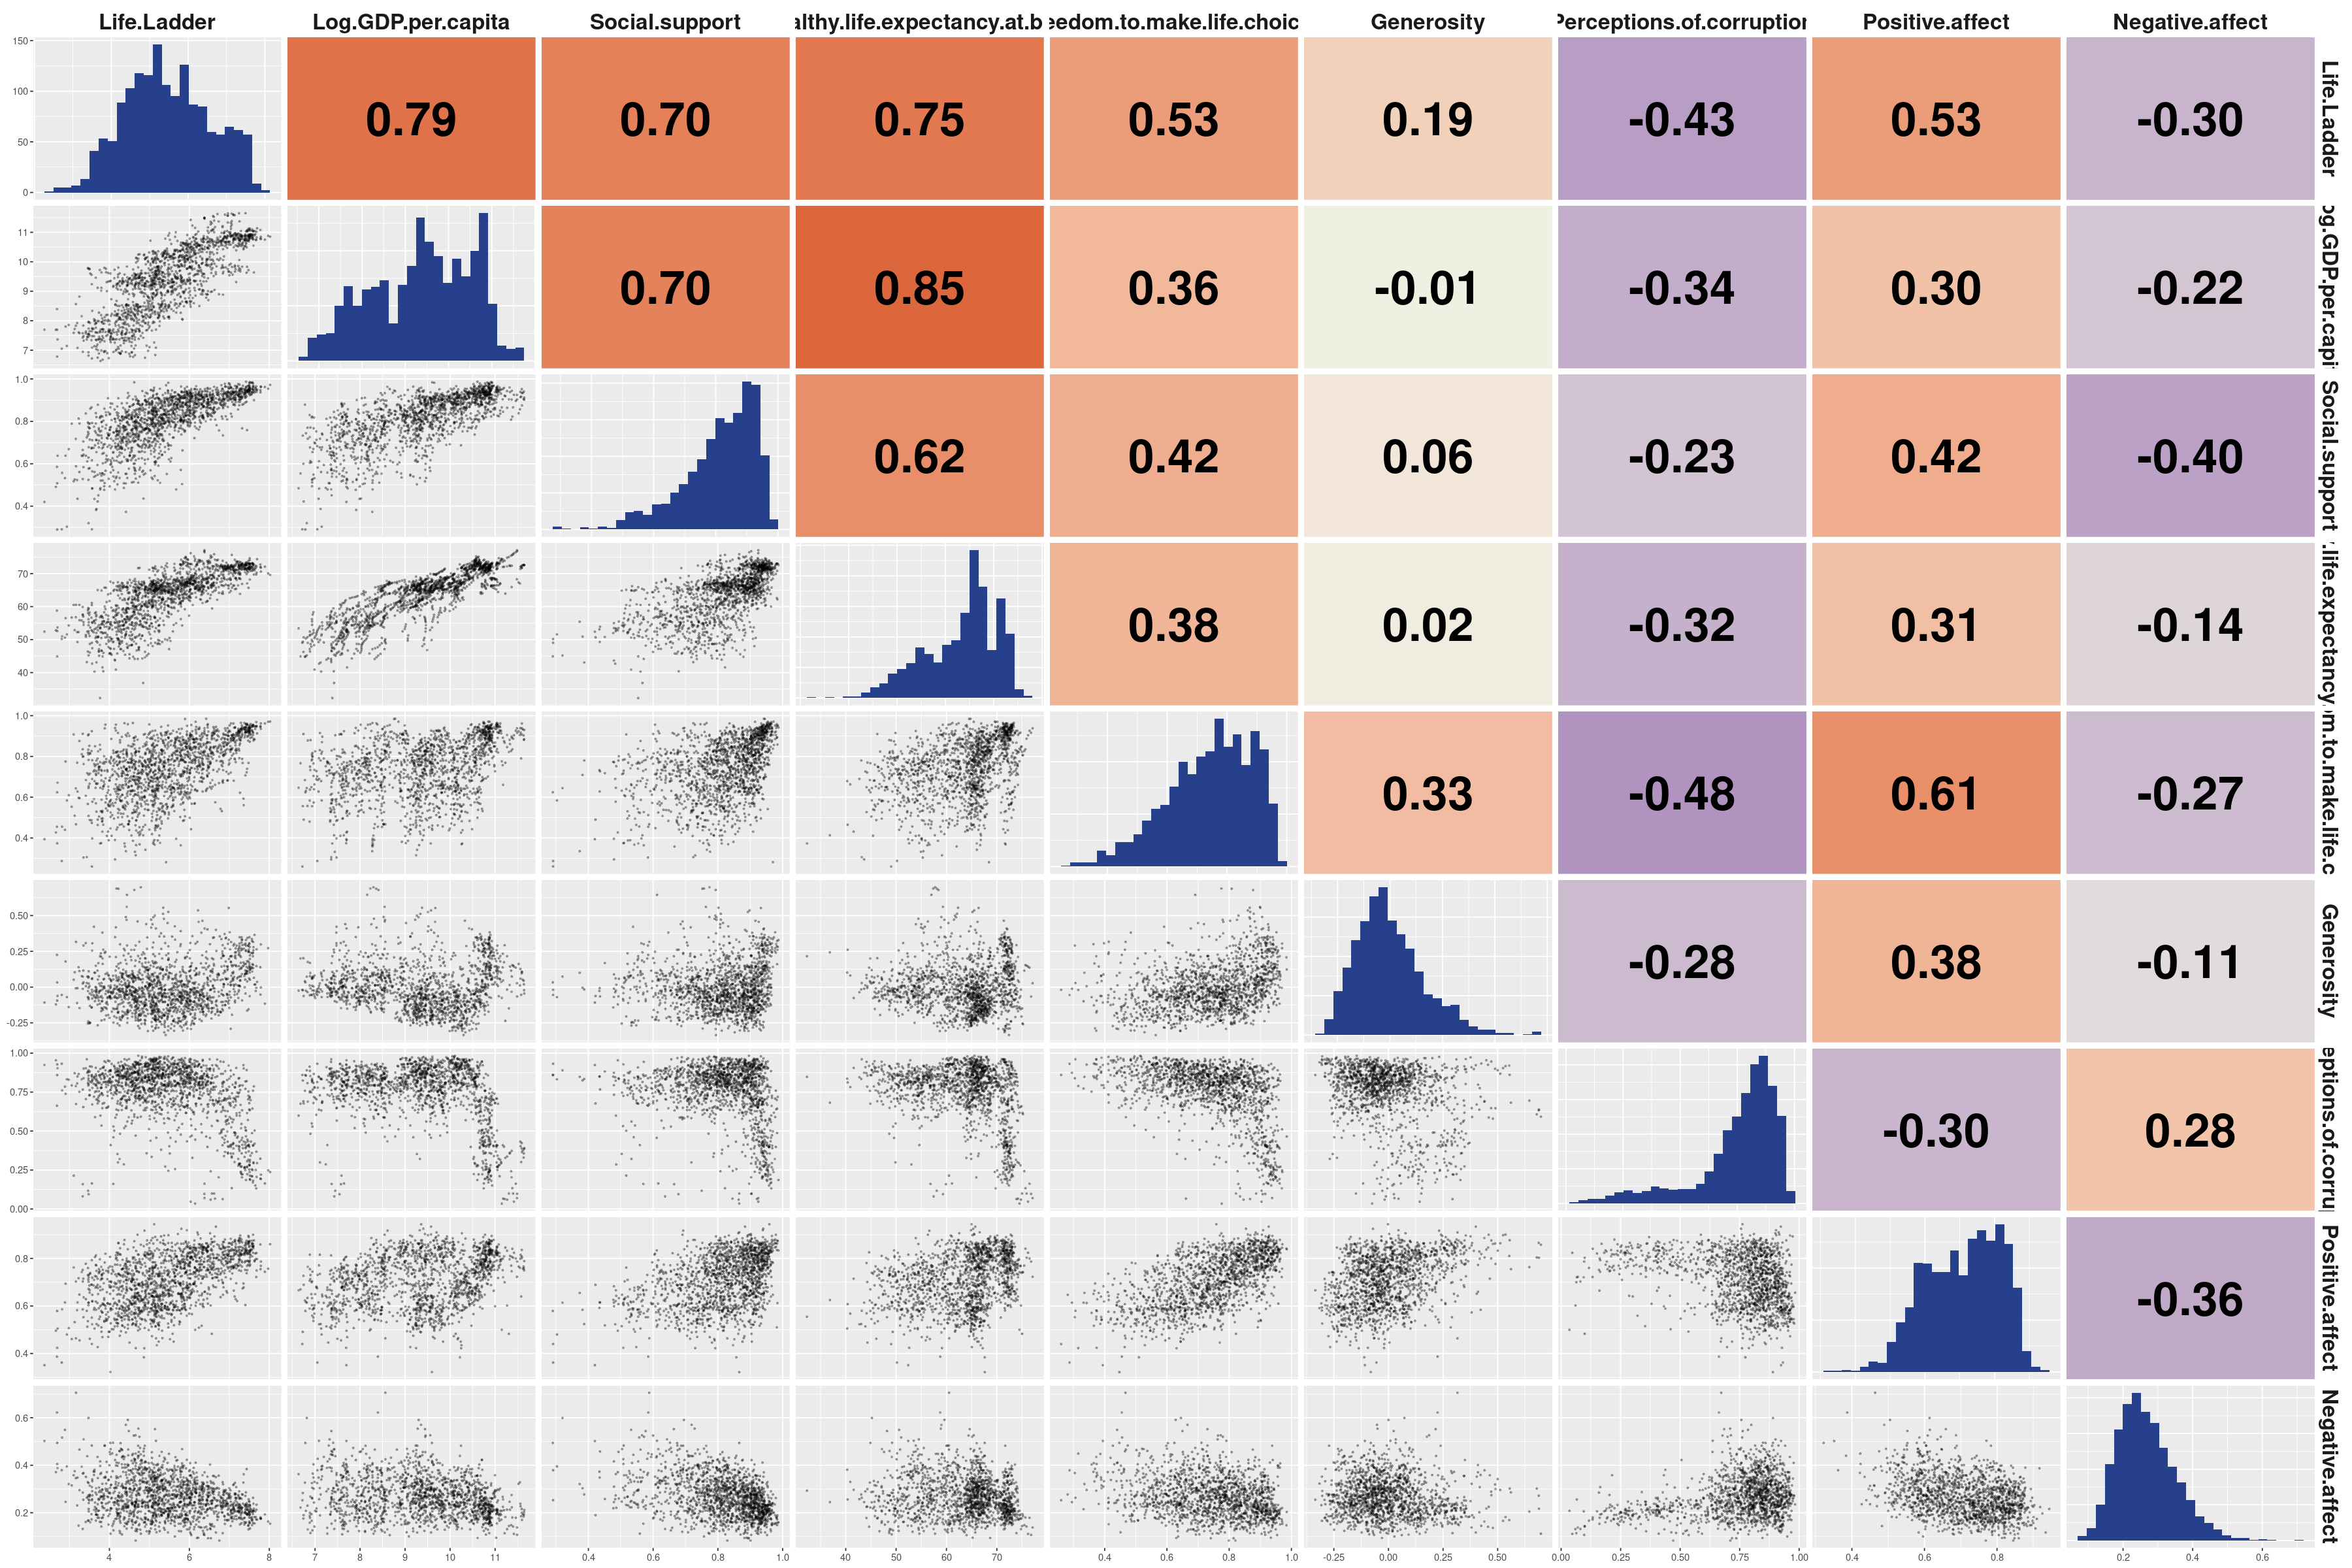

In [ ]:
options(warn=-1) # Suppress Warnings (Null Values)

heatmap <- function(data, mapping, ...) {
  x <- eval_data_col(data, mapping$x)
  y <- eval_data_col(data, mapping$y)

  # Pearson correlation
  p_corr = cor(x, y, use = "complete.obs", method = "pearson")

  # Fill color from correlation using color-mapping function on p_corr
  fill_color <- scales::col_numeric(
    palette = c("purple4","ivory2","orangered3"),
    domain = c(-1,1)
  )(p_corr)

  ggplot(data, mapping) +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -Inf, ymax = Inf,
             fill = fill_color, alpha = 0.9) +
    annotate("text", x = 0.5, y = 0.5,
             label = sprintf("%.2f", p_corr),
             size = 15, fontface = "bold", color = "black") +
    theme_void()
}


ggpairs(
  training_d,
  upper = list(continuous = heatmap),
  diag = list(continuous = wrap("barDiag", bins = 25, fill = "royalblue4")),
  lower = list(continuous = wrap("points", alpha = 0.3, size = 0.5)),
  aes()
) +
  theme(
    strip.text.x = element_text(size = 20, face = "bold"), # top labels
    strip.text.y = element_text(size = 20, face = "bold"), # right-side labels
    strip.placement = "outside",
    strip.background = element_rect(fill = "white", color = NA)
  )
options(warn=0)

Looking at the histograms (which consist of 25 bins each), the data generally follows unimodal distributions for all 9 variables. However, there is notable variability in Log GDP per Capita that is only readily apparent at these higher bin counts. Likewise, Life Expectancy has a very pronounced peak.

Regarding distributions, Social Support, Life Expectancy, Generosity, and Perceptions of Corruption have fairly strong skews, with Corruption's being the most pronounced. There are also pronounced dropoffs at higher values across most of the variables. For these dropoffs, we may want to exclude extreme values when training the model to help prevent skew.

TODO: Revisit special treatment for skewed data, trimming data range, and data holes.

# Part D
Train a Linear Regression model using the training data with four-fold cross-validation and with appropriate evaluation metric. Do this with a closed-form solution (using the Normal Equation or SVD) and with SGD. Then focus on SGD and perform Ridge, Lasso and Elastic Net regularization – try three values of penalty term and describe its impact. Explore the impact of other hyperparameters of your choice, such as learning rate (no need for grid search). Describe your findings. Select the best-performing regularization set of hyperparameters and train that model on the entire training dataset. For SGD, display the training and validation loss as a function of training epochs for the selected model. (Hint: In scikit-learn, max_iter counts epochs (full passes over the training set). To plot training/validation loss by epoch with SGDRegressor, set max_iter=1 and warm_start=True, then call fit(...) in a loop; after each call (each epoch), compute and record Train and Validation RMSE). Ensure reproducibility by using a seed. [10 points]

## Initialization

In [ ]:
set.seed(100725)
train_control <- trainControl(method = "cv", number = 4)

## Linear Model

In [ ]:
model_lm <- train(
  Life.Ladder ~ .,
  data = training_d,
  method = "lm", # Uses the Normal Equation internally
  trControl = train_control,
  metric = "RMSE",
  preProcess = c("center", "scale", "medianImpute"), # imputes median for na
  na.action = na.pass # Allow preProcess to handle missing values
)

## Elastic Models


### Definitions

In [ ]:
model_sgd <- train(
  Life.Ladder ~ .,
  data = training_d,
  method = "glmnet",
  trControl = train_control,
  metric = "RMSE",
  preProcess = c("center", "scale", "medianImpute"),
  tuneGrid = expand.grid( # tuneGrid adjust hyperparameters
    alpha = 0,
    lambda = 0
  ),
  na.action = na.pass # Allow preProcess to handle missing values
)

model_elastic <- function(penalty, a = 0.5) {
  train(
    Life.Ladder ~ .,
    data = training_d,
    method = "glmnet",
    trControl = train_control,
    metric = "RMSE",
    preProcess = c("center", "scale", "medianImpute"),
    tuneGrid = expand.grid(
      alpha = 0.5,
      lambda = penalty # Changed '1' to 'penalty' to use the argument
    ),
    na.action = na.pass # Allow preProcess to handle missing values
  )
}

model_ridge <- function(penalty){
  model_elastic(penalty = penalty, a=0)
}
model_lasso <- function(penalty) {
  model_elastic(penalty = penalty, a=1)
}

### Variants

In [ ]:
ridge_0.5 <- model_ridge(penalty = 0.5)
ridge_1.0 <- model_ridge(penalty = 1.0)
ridge_5.0 <- model_ridge(penalty = 5.0)

lasso_0.5 <- model_lasso(penalty = 0.5)
lasso_1.0 <- model_lasso(penalty = 1.0)
lasso_5.0 <- model_lasso(penalty = 5.0)

elastic_0.5 <- model_elastic(penalty = 0.5)
elastic_1.0 <- model_elastic(penalty = 1.0)
elastic_5.0 <- model_elastic(penalty = 5.0)

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


## Graphs

These graphs were generated using ChatGPT code. I don't know R well enough to fine tune to visualizations to this extent (yet).

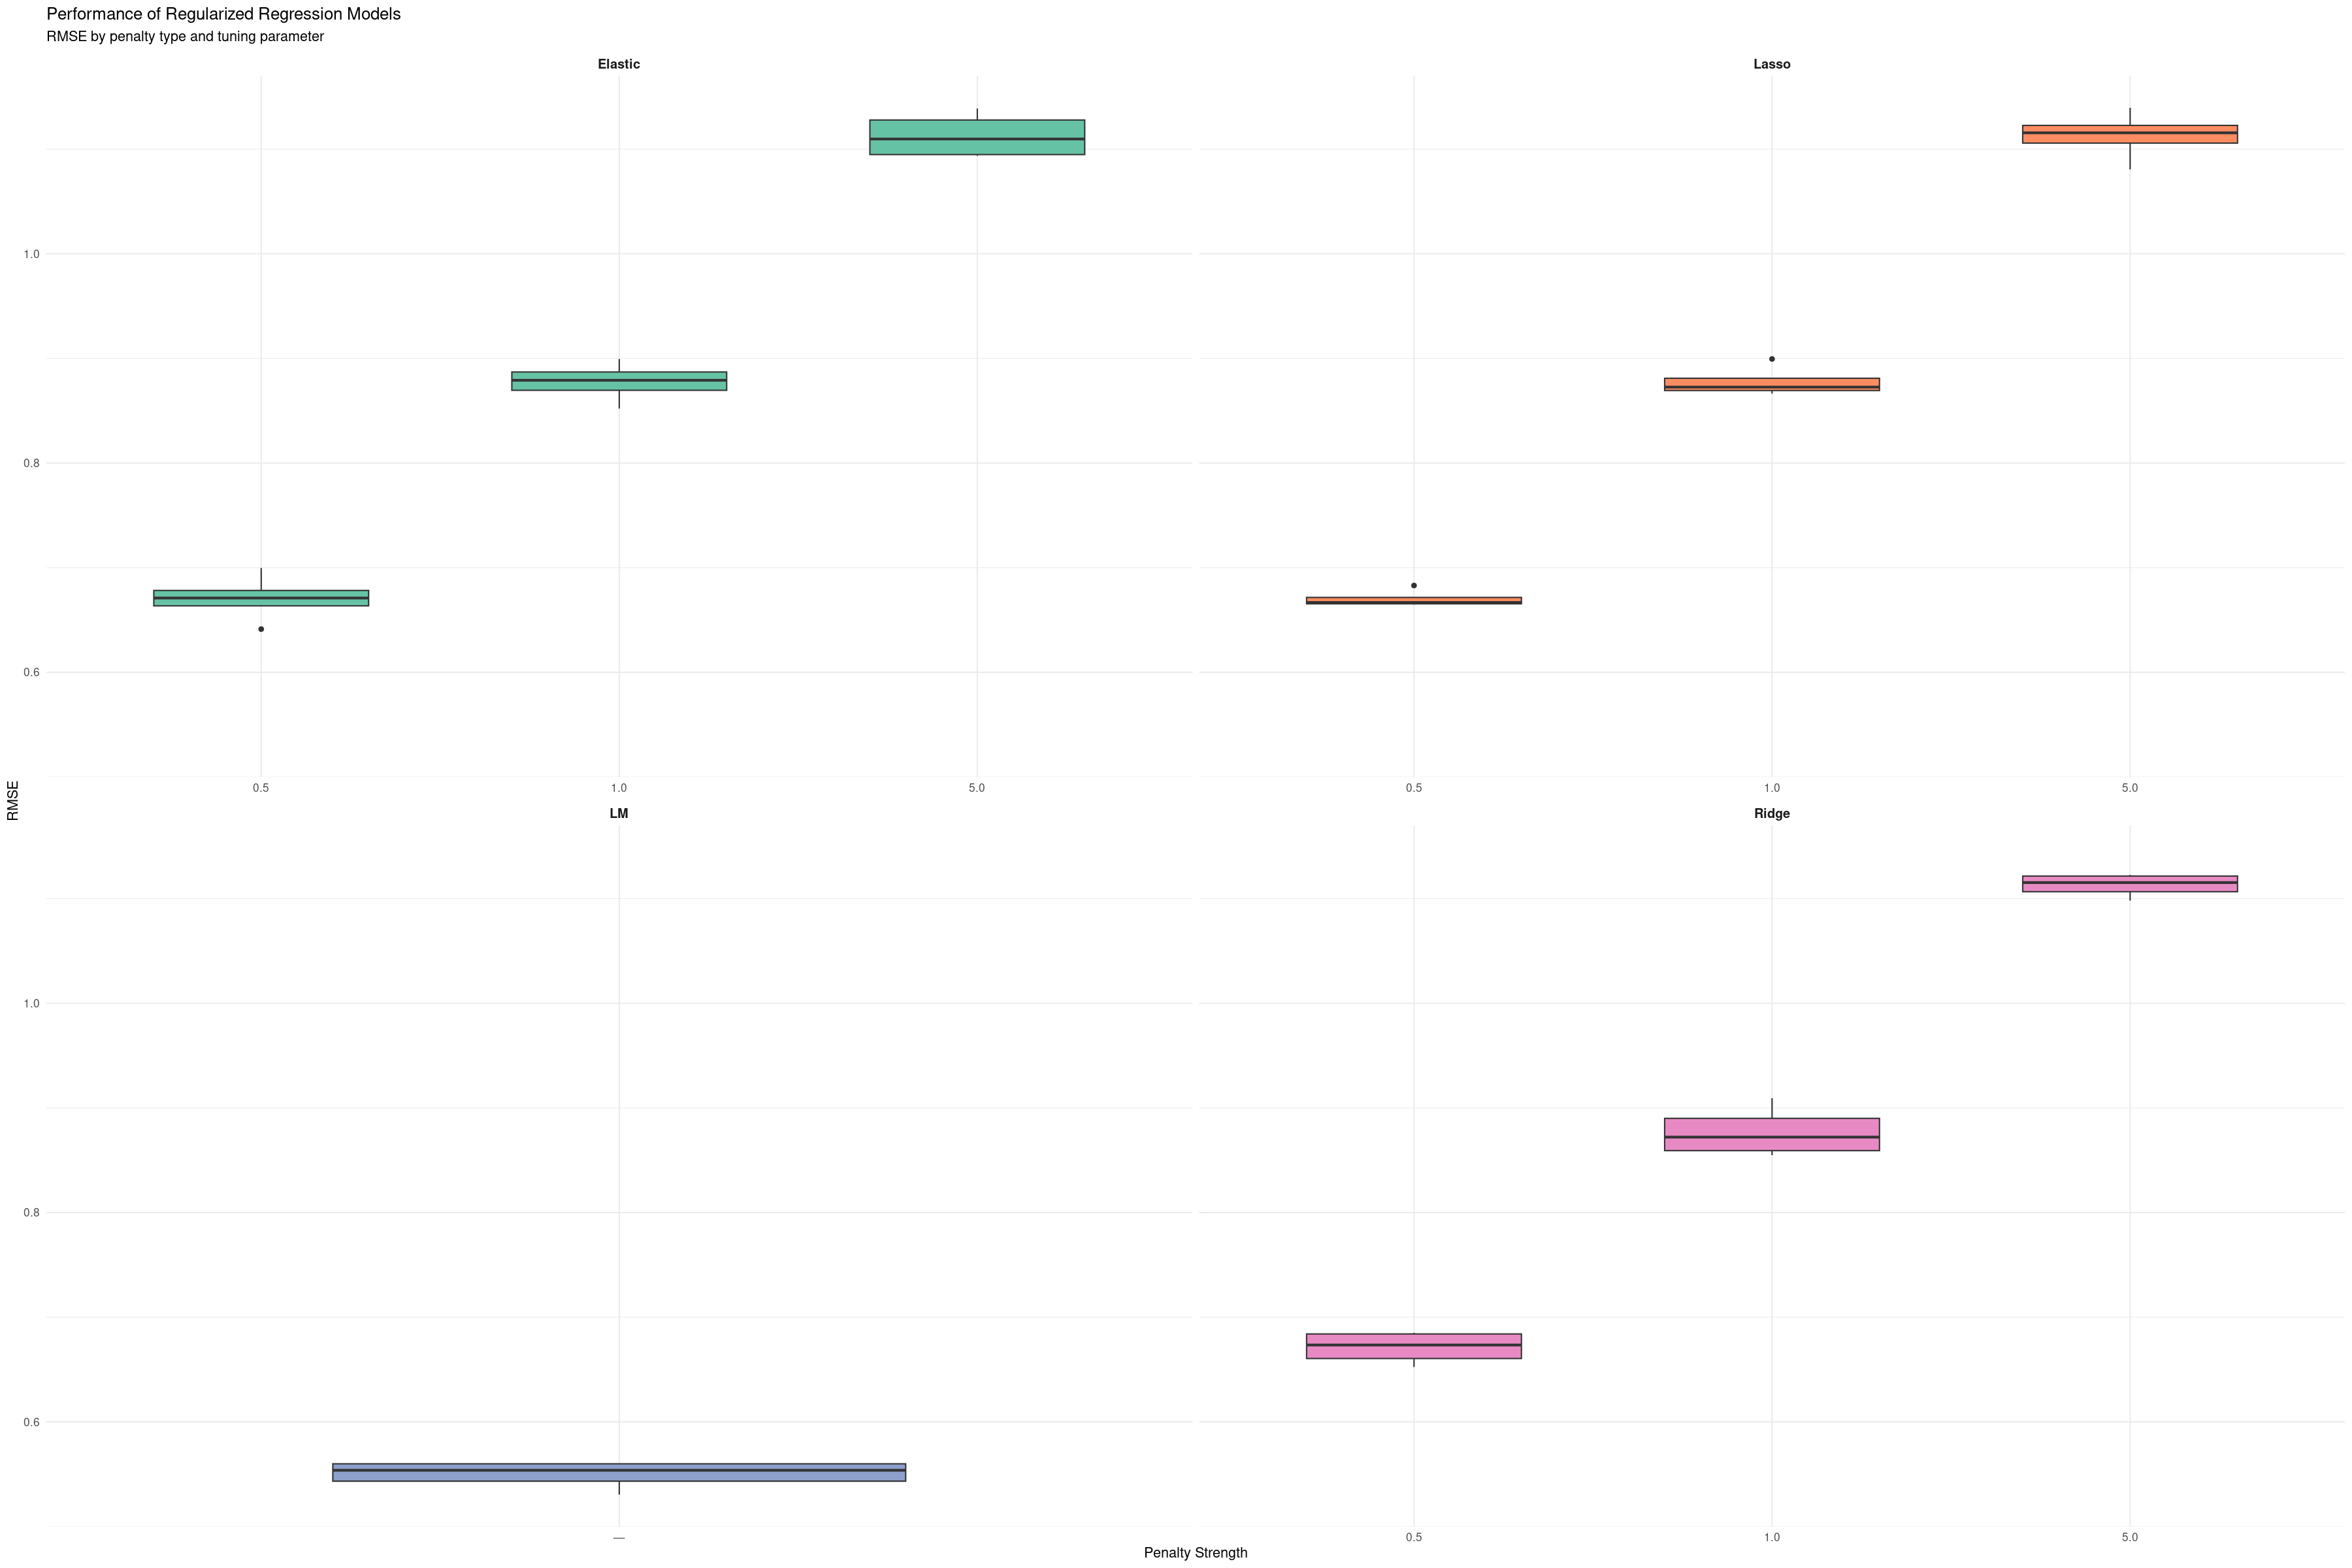

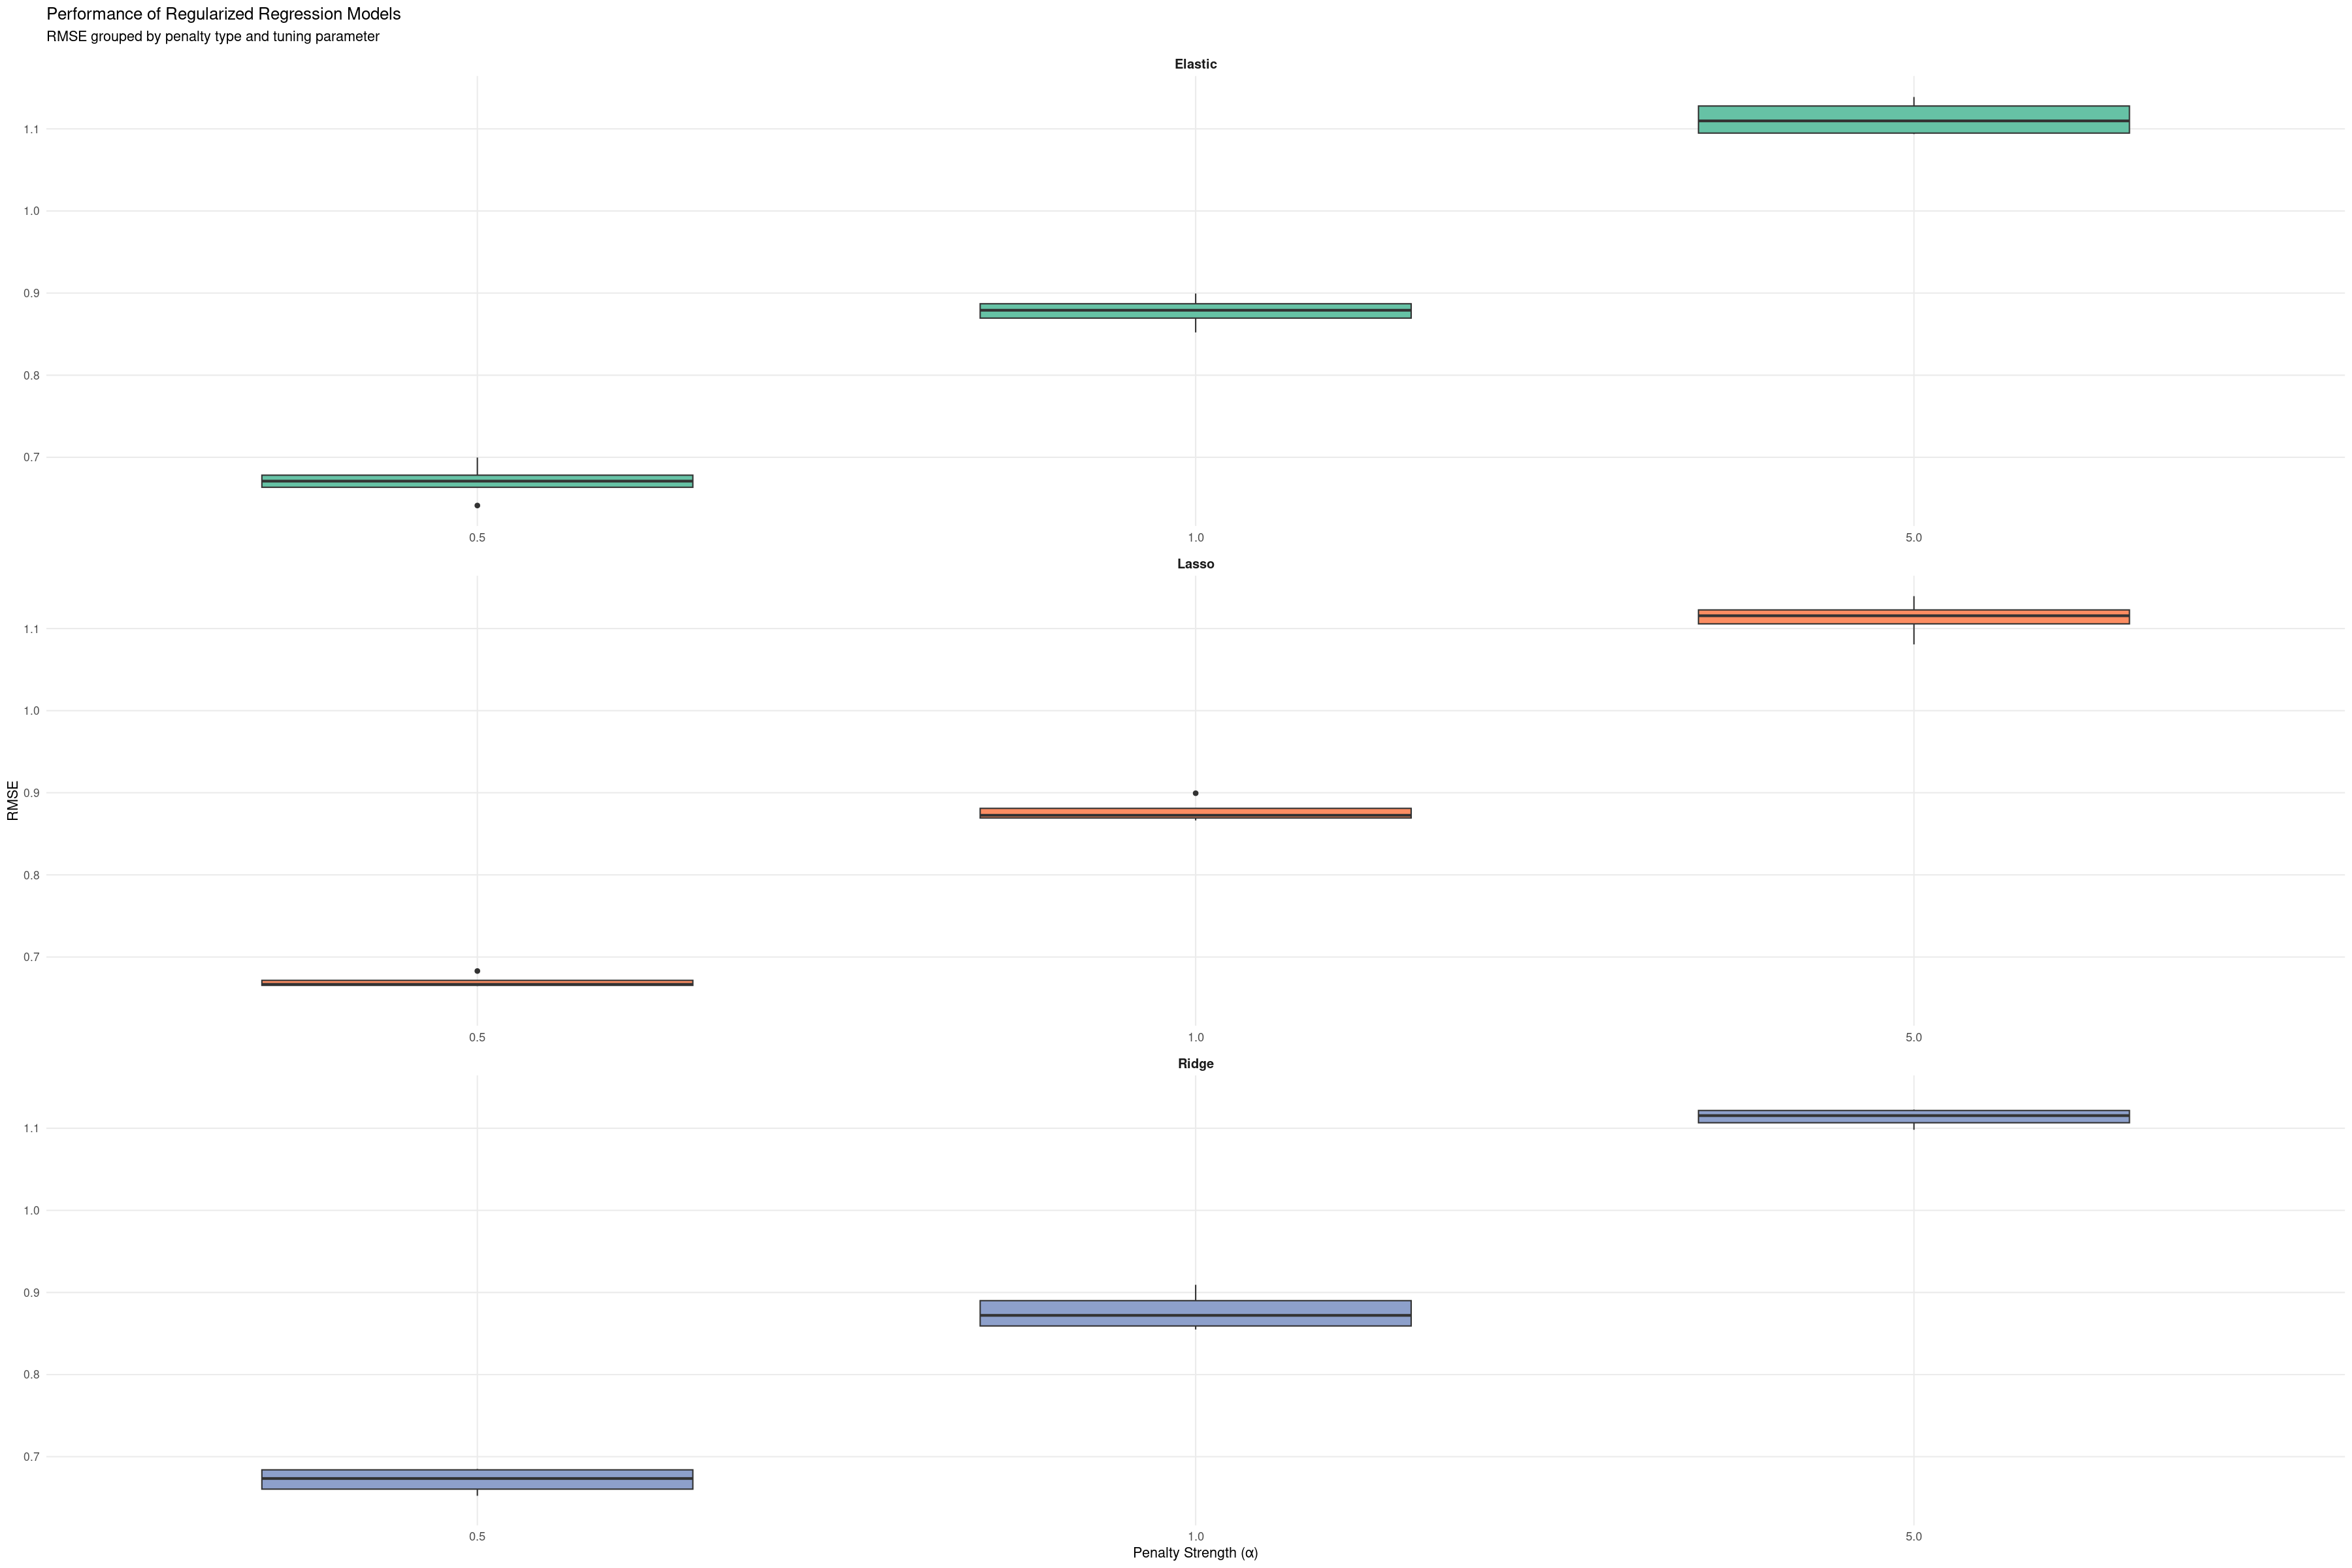

In [ ]:
resamps <- resamples(list(
  LM = model_lm,

  "Ridge (0.5)" = ridge_0.5,
  "Ridge (1.0)" = ridge_1.0,
  "Ridge (5.0)" = ridge_5.0,

  "Lasso (0.5)" = lasso_0.5,
  "Lasso (1.0)" = lasso_1.0,
  "Lasso (5.0)" = lasso_5.0,

  "Elastic (0.5)" = elastic_0.5,
  "Elastic (1.0)" = elastic_1.0,
  "Elastic (5.0)" = elastic_5.0
))


# Prepare data: same cleaning as before
res_df <- resamps$values %>%
  select(Resample, matches("~RMSE$")) %>%
  pivot_longer(
    cols = -Resample,
    names_to = "Model",
    values_to = "RMSE"
  ) %>%
  mutate(
    Model = str_remove(Model, "~RMSE$"),
    Group = case_when(
      grepl("^LM", Model) ~ "LM",
      grepl("^Ridge", Model) ~ "Ridge",
      grepl("^Lasso", Model) ~ "Lasso",
      grepl("^Elastic", Model) ~ "Elastic",
      TRUE ~ "Other"
    )
  )

# Extract the tuning parameter (e.g., 0.5, 1.0, 5.0)
res_df <- res_df %>%
  mutate(
    Alpha = str_extract(Model, "\\(.*\\)"),
    Alpha = str_remove_all(Alpha, "[()]"),
    Alpha = ifelse(is.na(Alpha), "—", Alpha)  # for LM
  )

# Define order within each group
res_df$Alpha <- factor(res_df$Alpha, levels = c("0.5", "1.0", "5.0", "—"))

# Plot each group (Ridge, Lasso, Elastic) in its own panel
ggplot(res_df,  # optional: drop LM if you like
       aes(x = Alpha, y = RMSE, fill = Group)) +
  geom_boxplot(width = 0.6) +
  facet_wrap(~ Group, scales = "free_x") +
  scale_fill_brewer(palette = "Set2") +
  theme_minimal(base_size = 13) +
  labs(
    title = "Performance of Regularized Regression Models",
    subtitle = "RMSE by penalty type and tuning parameter",
    y = "RMSE", x = "Penalty Strength"
  ) +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 12, face = "bold")
  )

# --- WITHOUT LM --- #

# Prepare data
res_df <- resamps$values %>%
  select(Resample, matches("~RMSE$")) %>%
  pivot_longer(
    cols = -Resample,
    names_to = "Model",
    values_to = "RMSE"
  ) %>%
  mutate(
    # Clean up names
    Model = str_remove(Model, "~RMSE$"),
    Group = case_when(
      grepl("^LM", Model) ~ "LM",
      grepl("^Ridge", Model) ~ "Ridge",
      grepl("^Lasso", Model) ~ "Lasso",
      grepl("^Elastic", Model) ~ "Elastic",
      TRUE ~ "Other"
    ),
    # Extract tuning parameter (0.5, 1.0, 5.0, etc.)
    Alpha = str_extract(Model, "\\(.*\\)"),
    Alpha = str_remove_all(Alpha, "[()]"),
    Alpha = ifelse(is.na(Alpha), "—", Alpha)
  )

# Define the order of Alpha values
res_df$Alpha <- factor(res_df$Alpha, levels = c("0.5", "1.0", "5.0", "—"))

# Optional: drop LM if you only want Ridge, Lasso, and Elastic
res_df_filtered <- res_df %>% filter(Group != "LM")

# Vertically faceted plot
ggplot(res_df_filtered, aes(x = Alpha, y = RMSE, fill = Group)) +
  geom_boxplot(width = 0.6) +
  facet_wrap(~ Group, scales = "free_x", ncol = 1) +  # vertical layout
  scale_fill_brewer(palette = "Set2") +
  theme_minimal(base_size = 13) +
  labs(
    title = "Performance of Regularized Regression Models",
    subtitle = "RMSE grouped by penalty type and tuning parameter",
    y = "RMSE", x = "Penalty Strength (α)"
  ) +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(size = 11),
    panel.grid.minor = element_blank()
  )

# References

The R library pages were instrumental in understanding how each worked, particularly for the ggpairs() function. ChatGPT assisted with some custom functions, such as the heatmap implementation for the Pearson's Coefficient. However, when used for programming elements, the code was always explained or stepped through to improve understanding.

https://www.r-bloggers.com/2021/10/cross-validation-in-r-with-example/

https://www.youtube.com/watch?v=BQ1VAZ7jNYQ

https://www.geeksforgeeks.org/r-language/k-fold-cross-validation-in-r-programming/

https://www.rdocumentation.org/packages/caret/versions/4.47/topics/train

https://medium.com/biased-algorithms/stochastic-gradient-descent-in-r-a692bee650d8

https://www.datacareer.ch/blog/ridge-and-lasso-in-r/